In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
df = pd.read_csv("sisepuede_raw_inputs_latest_LBY_oct_28.csv")
df.head()

,year,ef_ippu_tonne_nf3_per_tonne_production_chemicals,ef_ippu_tonne_nf3_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_mmm_gdp_other_product_manufacturing,ef_ippu_tonne_sf6_per_tonne_production_chemicals,ef_ippu_tonne_sf6_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_tonne_production_metals,frac_agrc_bevs_and_spices_cl2_dry,frac_agrc_cereals_cl2_dry,frac_agrc_fibers_cl2_dry,...,nemomod_entc_scalar_availability_factor_pp_gas_ccs,nemomod_entc_scalar_availability_factor_pp_geothermal,nemomod_entc_scalar_availability_factor_pp_hydropower,nemomod_entc_scalar_availability_factor_pp_nuclear,nemomod_entc_scalar_availability_factor_pp_ocean,nemomod_entc_scalar_availability_factor_pp_oil,nemomod_entc_scalar_availability_factor_pp_solar,nemomod_entc_scalar_availability_factor_pp_waste_incineration,nemomod_entc_scalar_availability_factor_pp_wind,iso_alpha_3
0,2015,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,LBY
1,2016,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,LBY
2,2017,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,LBY
3,2018,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,LBY
4,2019,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,LBY


### TRDE Elasticities

In [3]:
trde_elasticity_cols = [col for col in df.columns if "elasticity" in col.lower() and "trde" in col.lower()]
df[trde_elasticity_cols]

,elasticity_trde_pkm_to_gdppc_private_and_public,elasticity_trde_pkm_to_gdppc_regional,elasticity_trde_mtkm_to_gdp_freight
0,1.12,2.64,1.0
1,1.12,2.64,1.0
2,1.12,2.64,1.0
3,1.12,2.64,1.0
4,1.12,2.64,1.0
5,1.12,2.64,1.0
6,1.12,2.64,1.0
7,1.12,2.64,1.0
8,1.12,2.64,1.0
9,1.12,2.64,1.0


In [4]:
df[trde_elasticity_cols] = 0.8
df[trde_elasticity_cols]

,elasticity_trde_pkm_to_gdppc_private_and_public,elasticity_trde_pkm_to_gdppc_regional,elasticity_trde_mtkm_to_gdp_freight
0,0.8,0.8,0.8
1,0.8,0.8,0.8
2,0.8,0.8,0.8
3,0.8,0.8,0.8
4,0.8,0.8,0.8
5,0.8,0.8,0.8
6,0.8,0.8,0.8
7,0.8,0.8,0.8
8,0.8,0.8,0.8
9,0.8,0.8,0.8


### IPPU Elasticities

In [5]:
ippu_elasticity_cols = [col for col in df.columns if "elasticity" in col.lower() and "ippu" in col.lower()]
df[ippu_elasticity_cols]

,elasticity_ippu_cement_production_to_gdp,elasticity_ippu_chemicals_production_to_gdp,elasticity_ippu_electronics_production_to_gdp,elasticity_ippu_glass_production_to_gdp,elasticity_ippu_lime_and_carbonite_production_to_gdp,elasticity_ippu_metals_production_to_gdp,elasticity_ippu_mining_production_to_gdp,elasticity_ippu_paper_production_to_gdp,elasticity_ippu_plastic_production_to_gdp,elasticity_ippu_product_use_lubricants_product_use_rate_to_gdppc,elasticity_ippu_product_use_ods_other_product_use_rate_to_gdppc,elasticity_ippu_product_use_ods_refrigeration_product_use_rate_to_gdppc,elasticity_ippu_product_use_paraffin_wax_product_use_rate_to_gdppc,elasticity_ippu_rubber_and_leather_production_to_gdp,elasticity_ippu_textiles_production_to_gdp,elasticity_ippu_wood_production_to_gdp
0,28.277476,-19.363667,-10.371178,19.066233,42.059537,16.967509,15.711407,7.792454,-6.365421,0.01,0.01,0.01,0.01,7.262124,13.879090,0.5
1,14.726944,-28.143452,-55.984056,-50.004838,11.927801,-49.029891,-40.801225,-19.061907,-39.546275,0.01,0.01,0.01,0.01,-26.832748,-49.546792,0.5
2,1.975943,28.766378,38.457250,30.212123,29.369519,25.627065,23.604182,51.369948,39.920770,0.01,0.01,0.01,0.01,52.296187,34.141406,0.5
3,-4.982407,-1.196341,1.025687,10.814672,4.478882,1.033295,-2.633950,3.085947,10.202271,0.01,0.01,0.01,0.01,6.210359,1.663388,0.5
4,13.713241,-16.917346,14.070968,-17.278433,-49.917440,20.907289,0.141504,-20.762947,-2.651003,0.01,0.01,0.01,0.01,-16.208534,16.136001,0.5
5,0.540583,-0.500000,-0.500000,-0.484622,2.000000,0.696955,-0.500000,-0.221378,0.001046,0.01,0.01,0.01,0.01,1.082201,1.016299,0.5
6,0.555897,-0.450000,-0.450000,-0.435135,1.966667,0.707056,-0.450000,-0.180666,0.034345,0.01,0.01,0.01,0.01,1.079461,1.015755,0.5
7,0.571210,-0.400000,-0.400000,-0.385647,1.933333,0.717158,-0.400000,-0.139953,0.067643,0.01,0.01,0.01,0.01,1.076721,1.015212,0.5
8,0.586524,-0.350000,-0.350000,-0.336160,1.900000,0.727259,-0.350000,-0.099241,0.100942,0.01,0.01,0.01,0.01,1.073981,1.014669,0.5
9,0.601838,-0.300000,-0.300000,-0.286672,1.866667,0.737361,-0.300000,-0.058528,0.134240,0.01,0.01,0.01,0.01,1.071241,1.014125,0.5


In [ ]:
varying_cols = df[ippu_elasticity_cols].columns[df[ippu_elasticity_cols].nunique(dropna=False) > 1]
df.iloc[4:, df.columns.get_indexer(varying_cols)] = 0.8
df[ippu_elasticity_cols]


,elasticity_ippu_cement_production_to_gdp,elasticity_ippu_chemicals_production_to_gdp,elasticity_ippu_electronics_production_to_gdp,elasticity_ippu_glass_production_to_gdp,elasticity_ippu_lime_and_carbonite_production_to_gdp,elasticity_ippu_metals_production_to_gdp,elasticity_ippu_mining_production_to_gdp,elasticity_ippu_paper_production_to_gdp,elasticity_ippu_plastic_production_to_gdp,elasticity_ippu_product_use_lubricants_product_use_rate_to_gdppc,elasticity_ippu_product_use_ods_other_product_use_rate_to_gdppc,elasticity_ippu_product_use_ods_refrigeration_product_use_rate_to_gdppc,elasticity_ippu_product_use_paraffin_wax_product_use_rate_to_gdppc,elasticity_ippu_rubber_and_leather_production_to_gdp,elasticity_ippu_textiles_production_to_gdp,elasticity_ippu_wood_production_to_gdp
0,28.277476,-19.363667,-10.371178,19.066233,42.059537,16.967509,15.711407,7.792454,-6.365421,0.01,0.01,0.01,0.01,7.262124,13.879090,0.5
1,14.726944,-28.143452,-55.984056,-50.004838,11.927801,-49.029891,-40.801225,-19.061907,-39.546275,0.01,0.01,0.01,0.01,-26.832748,-49.546792,0.5
2,1.975943,28.766378,38.457250,30.212123,29.369519,25.627065,23.604182,51.369948,39.920770,0.01,0.01,0.01,0.01,52.296187,34.141406,0.5
3,-4.982407,-1.196341,1.025687,10.814672,4.478882,1.033295,-2.633950,3.085947,10.202271,0.01,0.01,0.01,0.01,6.210359,1.663388,0.5
4,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.01,0.01,0.01,0.01,0.010000,0.010000,0.5
5,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.01,0.01,0.01,0.01,0.010000,0.010000,0.5
6,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.01,0.01,0.01,0.01,0.010000,0.010000,0.5
7,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.01,0.01,0.01,0.01,0.010000,0.010000,0.5
8,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.01,0.01,0.01,0.01,0.010000,0.010000,0.5
9,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.01,0.01,0.01,0.01,0.010000,0.010000,0.5


### SCOE Elasticities

In [7]:
scoe_elasticity_cols = [col for col in df.columns if "elasticity" in col.lower() and "scoe" in col.lower()]
df[scoe_elasticity_cols]

,elasticity_scoe_enerdem_per_hh_residential_elec_appliances_to_gdppc,elasticity_scoe_enerdem_per_hh_residential_heat_energy_to_gdppc,elasticity_scoe_enerdem_per_mmmgdp_commercial_municipal_elec_appliances_to_gdppc,elasticity_scoe_enerdem_per_mmmgdp_commercial_municipal_heat_energy_to_gdppc,elasticity_scoe_enerdem_per_mmmgdp_other_se_elec_appliances_to_gdppc,elasticity_scoe_enerdem_per_mmmgdp_other_se_heat_energy_to_gdppc
0,0.960264,0.960264,-0.118828,-0.118828,0.0,0.0
1,-1.192964,-1.192964,-6.451816,-6.451816,0.0,0.0
2,-2.697282,-2.697282,-10.640919,-10.640919,0.0,0.0
3,-0.168604,-0.168604,-3.263942,-3.263942,0.0,0.0
4,-0.756220,-0.756220,13.070074,13.070074,0.0,0.0
5,-0.098299,-0.098299,-0.500000,-0.500000,1.0,1.0
6,-0.061689,-0.061689,-0.450000,-0.450000,1.0,1.0
7,-0.025079,-0.025079,-0.400000,-0.400000,1.0,1.0
8,0.011531,0.011531,-0.350000,-0.350000,1.0,1.0
9,0.048141,0.048141,-0.300000,-0.300000,1.0,1.0


In [8]:
scoe_other_se_elasticity_cols = [col for col in df.columns if "elasticity" in col.lower() and "elasticity_scoe_enerdem_per_mmmgdp_other_se" in col.lower()]
scoe_other_se_elasticity_cols

['elasticity_scoe_enerdem_per_mmmgdp_other_se_elec_appliances_to_gdppc',
 'elasticity_scoe_enerdem_per_mmmgdp_other_se_heat_energy_to_gdppc']

In [9]:
df.iloc[5:, df.columns.get_indexer(scoe_other_se_elasticity_cols)] = 0.01
df[scoe_other_se_elasticity_cols].head(10)

,elasticity_scoe_enerdem_per_mmmgdp_other_se_elec_appliances_to_gdppc,elasticity_scoe_enerdem_per_mmmgdp_other_se_heat_energy_to_gdppc
0,0.00,0.00
1,0.00,0.00
2,0.00,0.00
3,0.00,0.00
4,0.00,0.00
5,0.01,0.01
6,0.01,0.01
7,0.01,0.01
8,0.01,0.01
9,0.01,0.01


In [10]:
scoe_comm_munic_elasticity_cols = [col for col in df.columns if "elasticity" in col.lower() and "elasticity_scoe_enerdem_per_mmmgdp_commercial_municipal" in col.lower()]
scoe_comm_munic_elasticity_cols

['elasticity_scoe_enerdem_per_mmmgdp_commercial_municipal_elec_appliances_to_gdppc',
 'elasticity_scoe_enerdem_per_mmmgdp_commercial_municipal_heat_energy_to_gdppc']

In [ ]:
df.iloc[16:, df.columns.get_indexer(scoe_comm_munic_elasticity_cols)] = 0.8
df[scoe_comm_munic_elasticity_cols].head(20)

,elasticity_scoe_enerdem_per_mmmgdp_commercial_municipal_elec_appliances_to_gdppc,elasticity_scoe_enerdem_per_mmmgdp_commercial_municipal_heat_energy_to_gdppc
0,-0.118828,-0.118828
1,-6.451816,-6.451816
2,-10.640919,-10.640919
3,-3.263942,-3.263942
4,13.070074,13.070074
5,-0.500000,-0.500000
6,-0.450000,-0.450000
7,-0.400000,-0.400000
8,-0.350000,-0.350000
9,-0.300000,-0.300000


In [12]:
scoe_residential_elasticity_cols = [col for col in df.columns if "elasticity" in col.lower() and "elasticity_scoe_enerdem_per_hh_residential" in col.lower()]
scoe_residential_elasticity_cols

['elasticity_scoe_enerdem_per_hh_residential_elec_appliances_to_gdppc',
 'elasticity_scoe_enerdem_per_hh_residential_heat_energy_to_gdppc']

In [13]:
df.iloc[8:, df.columns.get_indexer(scoe_residential_elasticity_cols)] = 0.01
df[scoe_residential_elasticity_cols].head(20)

,elasticity_scoe_enerdem_per_hh_residential_elec_appliances_to_gdppc,elasticity_scoe_enerdem_per_hh_residential_heat_energy_to_gdppc
0,0.960264,0.960264
1,-1.192964,-1.192964
2,-2.697282,-2.697282
3,-0.168604,-0.168604
4,-0.756220,-0.756220
5,-0.098299,-0.098299
6,-0.061689,-0.061689
7,-0.025079,-0.025079
8,0.010000,0.010000
9,0.010000,0.010000


In [14]:
scoe_elasticity_cols = [col for col in df.columns if "elasticity" in col.lower() and "scoe" in col.lower()]
df[scoe_elasticity_cols]

,elasticity_scoe_enerdem_per_hh_residential_elec_appliances_to_gdppc,elasticity_scoe_enerdem_per_hh_residential_heat_energy_to_gdppc,elasticity_scoe_enerdem_per_mmmgdp_commercial_municipal_elec_appliances_to_gdppc,elasticity_scoe_enerdem_per_mmmgdp_commercial_municipal_heat_energy_to_gdppc,elasticity_scoe_enerdem_per_mmmgdp_other_se_elec_appliances_to_gdppc,elasticity_scoe_enerdem_per_mmmgdp_other_se_heat_energy_to_gdppc
0,0.960264,0.960264,-0.118828,-0.118828,0.00,0.00
1,-1.192964,-1.192964,-6.451816,-6.451816,0.00,0.00
2,-2.697282,-2.697282,-10.640919,-10.640919,0.00,0.00
3,-0.168604,-0.168604,-3.263942,-3.263942,0.00,0.00
4,-0.756220,-0.756220,13.070074,13.070074,0.00,0.00
5,-0.098299,-0.098299,-0.500000,-0.500000,0.01,0.01
6,-0.061689,-0.061689,-0.450000,-0.450000,0.01,0.01
7,-0.025079,-0.025079,-0.400000,-0.400000,0.01,0.01
8,0.010000,0.010000,-0.350000,-0.350000,0.01,0.01
9,0.010000,0.010000,-0.300000,-0.300000,0.01,0.01


### WASO Elasticities

In [15]:
# waso_elasticity_cols = [col for col in df.columns if "elasticity" in col.lower() and "waso" in col.lower()]
# df[waso_elasticity_cols]

In [16]:
# cols_not_full_of_zeros = [col for col in waso_elasticity_cols if not (df[col] == 0).all()]
# df[cols_not_full_of_zeros] = 0.01
# df[waso_elasticity_cols]

### Livestock

In [17]:
lvst_elasticity_cols = [col for col in df.columns if "elasticity" in col.lower() and "lvst" in col.lower()]
df[lvst_elasticity_cols]

,elasticity_lvst_buffalo_demand_to_gdppc,elasticity_lvst_cattle_dairy_demand_to_gdppc,elasticity_lvst_cattle_nondairy_demand_to_gdppc,elasticity_lvst_chickens_demand_to_gdppc,elasticity_lvst_goats_demand_to_gdppc,elasticity_lvst_horses_demand_to_gdppc,elasticity_lvst_mules_demand_to_gdppc,elasticity_lvst_pigs_demand_to_gdppc,elasticity_lvst_sheep_demand_to_gdppc
0,0.220,0.050,0.390,0.650,0.420,0.420,0.420,0.390,0.420
1,0.217,0.049,0.385,0.644,0.415,0.415,0.415,0.385,0.415
2,0.214,0.048,0.380,0.638,0.410,0.410,0.410,0.380,0.410
3,0.211,0.047,0.375,0.632,0.405,0.405,0.405,0.375,0.405
4,0.208,0.046,0.370,0.626,0.400,0.400,0.400,0.370,0.400
5,0.205,0.045,0.365,0.620,0.395,0.395,0.395,0.365,0.395
6,0.202,0.044,0.360,0.614,0.390,0.390,0.390,0.360,0.390
7,0.199,0.043,0.355,0.608,0.385,0.385,0.385,0.355,0.385
8,0.196,0.042,0.350,0.602,0.380,0.380,0.380,0.350,0.380
9,0.193,0.041,0.345,0.596,0.375,0.375,0.375,0.345,0.375


In [18]:
df[lvst_elasticity_cols] = 0.01
df[lvst_elasticity_cols]

,elasticity_lvst_buffalo_demand_to_gdppc,elasticity_lvst_cattle_dairy_demand_to_gdppc,elasticity_lvst_cattle_nondairy_demand_to_gdppc,elasticity_lvst_chickens_demand_to_gdppc,elasticity_lvst_goats_demand_to_gdppc,elasticity_lvst_horses_demand_to_gdppc,elasticity_lvst_mules_demand_to_gdppc,elasticity_lvst_pigs_demand_to_gdppc,elasticity_lvst_sheep_demand_to_gdppc
0,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
1,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
2,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
3,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
4,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
6,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
7,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
8,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
9,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01


### Crops

In [19]:
agrc_elasticity_cols = [col for col in df.columns if "elasticity" in col.lower() and "agrc" in col.lower()]
df[agrc_elasticity_cols]

,elasticity_agrc_bevs_and_spices_demand_to_income,elasticity_agrc_cereals_demand_to_income,elasticity_agrc_fibers_demand_to_income,elasticity_agrc_fruits_demand_to_income,elasticity_agrc_herbs_and_other_perennial_crops_demand_to_income,elasticity_agrc_nuts_demand_to_income,elasticity_agrc_other_annual_demand_to_income,elasticity_agrc_other_woody_perennial_demand_to_income,elasticity_agrc_pulses_demand_to_income,elasticity_agrc_rice_demand_to_income,elasticity_agrc_sugar_cane_demand_to_income,elasticity_agrc_tubers_demand_to_income,elasticity_agrc_vegetables_and_vines_demand_to_income
0,0.291725,0.194484,0.194484,0.243104,0.194484,0.243104,0.194484,0.194484,0.194484,0.097242,0.048621,0.243104,0.243104
1,0.291725,0.194484,0.194484,0.243104,0.194484,0.243104,0.194484,0.194484,0.194484,0.097242,0.048621,0.243104,0.243104
2,0.291725,0.194484,0.194484,0.243104,0.194484,0.243104,0.194484,0.194484,0.194484,0.097242,0.048621,0.243104,0.243104
3,0.291725,0.194484,0.194484,0.243104,0.194484,0.243104,0.194484,0.194484,0.194484,0.097242,0.048621,0.243104,0.243104
4,0.291725,0.194484,0.194484,0.243104,0.194484,0.243104,0.194484,0.194484,0.194484,0.097242,0.048621,0.243104,0.243104
5,0.291725,0.194484,0.194484,0.243104,0.194484,0.243104,0.194484,0.194484,0.194484,0.097242,0.048621,0.243104,0.243104
6,0.291725,0.194484,0.194484,0.243104,0.194484,0.243104,0.194484,0.194484,0.194484,0.097242,0.048621,0.243104,0.243104
7,0.291725,0.194484,0.194484,0.243104,0.194484,0.243104,0.194484,0.194484,0.194484,0.097242,0.048621,0.243104,0.243104
8,0.291725,0.194484,0.194484,0.243104,0.194484,0.243104,0.194484,0.194484,0.194484,0.097242,0.048621,0.243104,0.243104
9,0.291725,0.194484,0.194484,0.243104,0.194484,0.243104,0.194484,0.194484,0.194484,0.097242,0.048621,0.243104,0.243104


In [20]:
df[agrc_elasticity_cols] = 0.01
df[agrc_elasticity_cols]

,elasticity_agrc_bevs_and_spices_demand_to_income,elasticity_agrc_cereals_demand_to_income,elasticity_agrc_fibers_demand_to_income,elasticity_agrc_fruits_demand_to_income,elasticity_agrc_herbs_and_other_perennial_crops_demand_to_income,elasticity_agrc_nuts_demand_to_income,elasticity_agrc_other_annual_demand_to_income,elasticity_agrc_other_woody_perennial_demand_to_income,elasticity_agrc_pulses_demand_to_income,elasticity_agrc_rice_demand_to_income,elasticity_agrc_sugar_cane_demand_to_income,elasticity_agrc_tubers_demand_to_income,elasticity_agrc_vegetables_and_vines_demand_to_income
0,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
1,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
2,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
3,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
4,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
6,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
7,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
8,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
9,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01


## Crude and Petroleum Mods

<Axes: title={'center': 'Crude Oil Exports Projection'}, xlabel='Time Period', ylabel='PJ'>

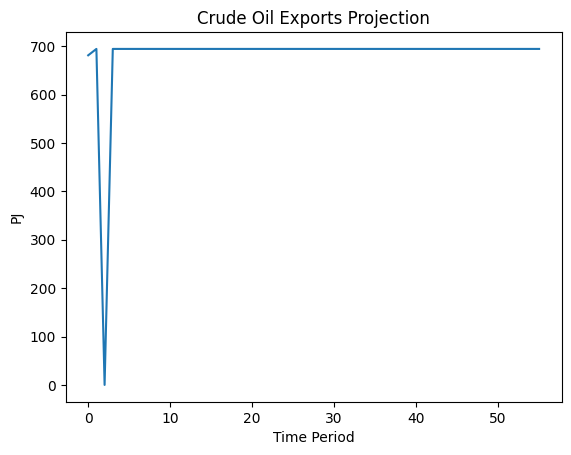

In [21]:
exports_var = "exports_enfu_pj_fuel_crude"
df[exports_var].plot(kind="line", title="Crude Oil Exports Projection", ylabel="PJ", xlabel="Time Period")

<Axes: title={'center': 'Crude Oil Imports Projection'}, xlabel='Time Period', ylabel='Fraction'>

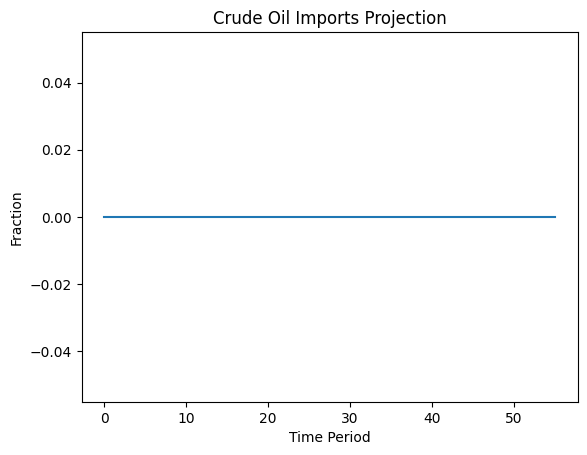

In [22]:
imports_var= "frac_enfu_fuel_demand_imported_pj_fuel_crude"
df[imports_var].plot(kind="line", title="Crude Oil Imports Projection", ylabel="Fraction", xlabel="Time Period")

### Update exports for crude oil

According to the IEA (https://www.iea.org/countries/libya/oil), Libya produced 2,617,486 TJ of crude oil in 2023 and it exported 86% of it. The trend in crude oil exports grew 3% in the period 2000-2023. The production trend shows a decrease of 12% from 2000-2023.

In [23]:
pj_export_total = (2617486 / 1000) * 0.86  # TJ to PJ conversion
pj_export_total

2251.0379599999997

<Axes: title={'center': 'Updated Crude Oil Exports Projection'}, xlabel='Time Period', ylabel='PJ'>

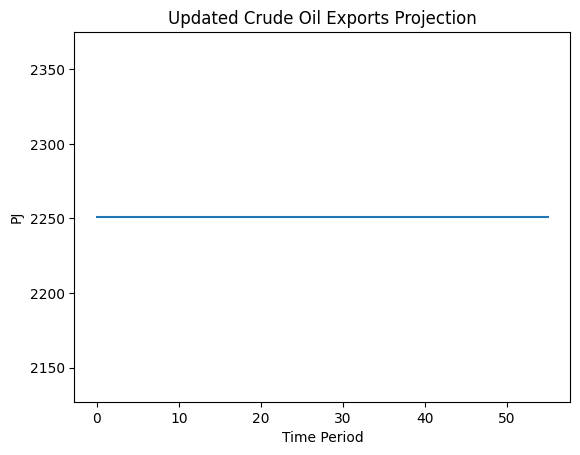

In [24]:
# Update exports for crude oil
df[exports_var] = pj_export_total
df[exports_var].plot(kind="line", title="Updated Crude Oil Exports Projection", ylabel="PJ", xlabel="Time Period")

### Check Exports and imports of petroleum derived products

- Gasoline.
- Oil.
- Hydrocarbon Gas Liquids.
- Kerosene.
- Diesel

In [25]:
petroleum_products = [
    "gasoline",
    "oil",
    "hydrocarbon_gas_liquids",
    "kerosene",
    "diesel"
]

In [26]:
def plot_columns_subplots(df, columns, x_col=None, kind='line', figsize=None,
                          sharex=True, titles=None, ylabels=None, suptitle=None):
    """
    Plot a list of columns (or lists of columns) as stacked subplots.

    - df: DataFrame
    - columns: list where each item is either a column name (str) or a list of column names to plot on the same subplot
    - x_col: column name to use for x axis (if None or missing, df.index is used)
    - kind: 'line' or 'bar' (defaults to 'line')
    - figsize: tuple, default is (10, 3 * n_subplots)
    - sharex: whether subplots share x axis
    - titles: optional list of subplot titles (length must match number of subplots)
    - ylabels: optional list of y labels (length must match number of subplots)
    - suptitle: optional figure title

    Returns: (fig, axes)
    """
    # normalize columns entries to lists
    cols_list = [([c] if isinstance(c, str) else list(c)) for c in columns]
    n = len(cols_list)
    if figsize is None:
        figsize = (10, 3 * n)

    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=figsize, sharex=sharex)
    if n == 1:
        axes = [axes]

    x = df[x_col] if (x_col and x_col in df.columns) else df.index

    for i, (ax, cols) in enumerate(zip(axes, cols_list)):
        plotted = False
        for col in cols:
            if col in df.columns:
                if kind == 'line':
                    ax.plot(x, df[col], label=col)
                elif kind == 'bar':
                    ax.bar(x, df[col], label=col)
                else:
                    ax.plot(x, df[col], label=col)
                plotted = True

        if not plotted:
            ax.text(0.5, 0.5, "No data for these columns",
                    ha="center", va="center", transform=ax.transAxes)

        title = titles[i] if (titles and i < len(titles)) else ", ".join(cols)
        ylabel = ylabels[i] if (ylabels and i < len(ylabels)) else ""
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.grid(True)
        ax.legend()

    xlabel = x_col if (x_col and x_col in df.columns) else "Index"
    axes[-1].set_xlabel(xlabel)

    if suptitle:
        fig.suptitle(suptitle)
        fig.subplots_adjust(top=0.92)

    fig.tight_layout()
    plt.show()
    return fig, axes

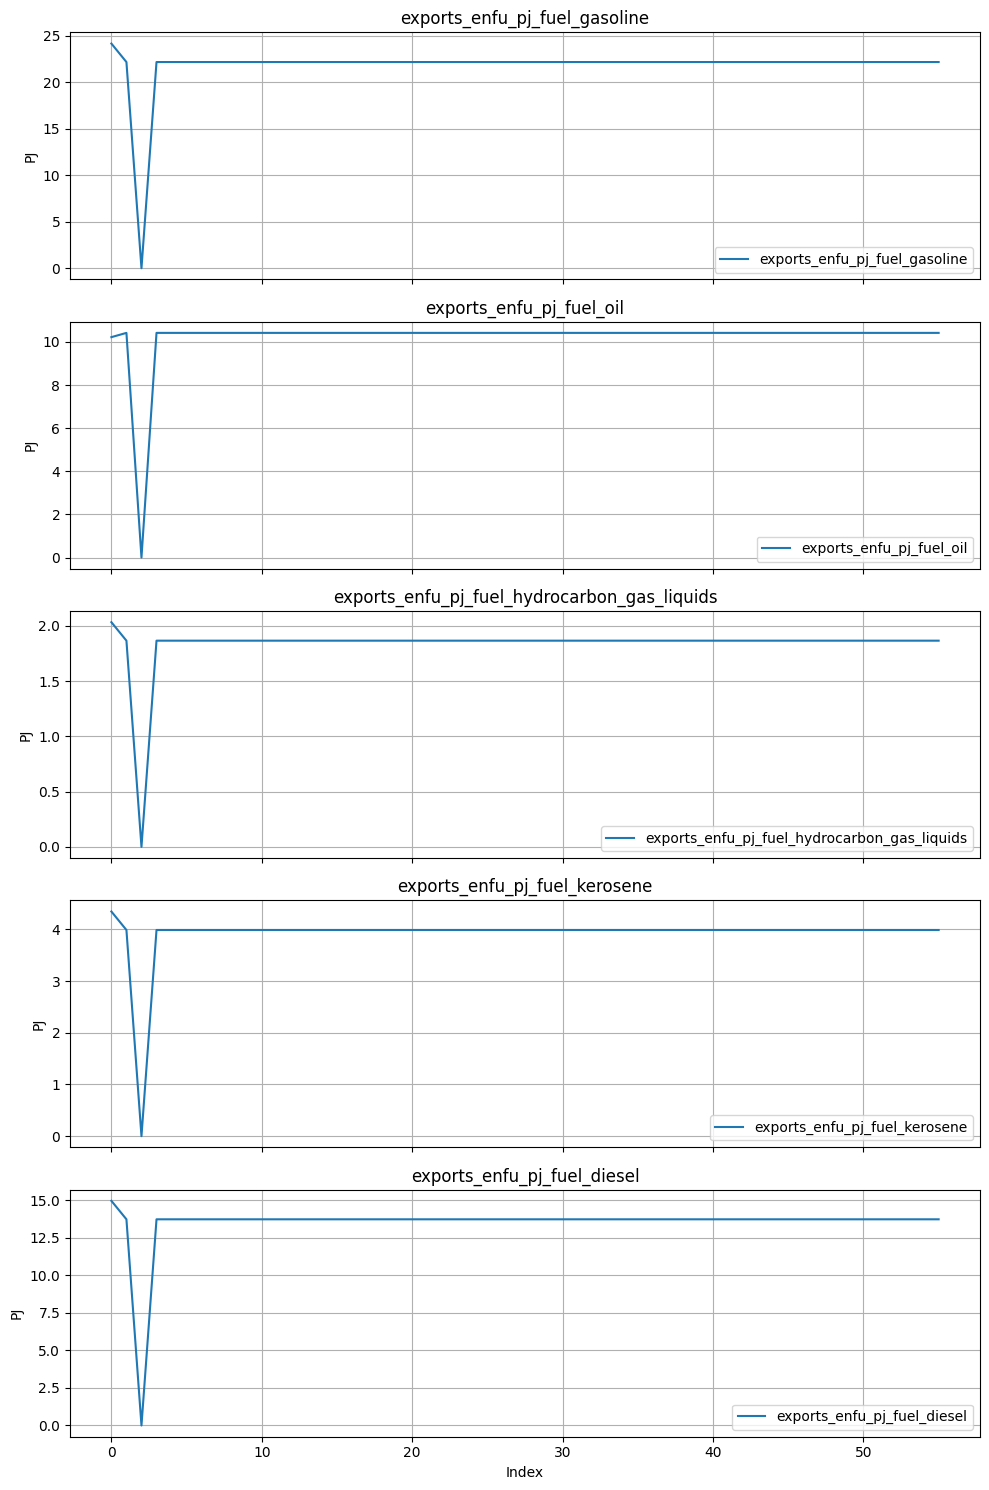

(<Figure size 1000x1500 with 5 Axes>,
 array([<Axes: title={'center': 'exports_enfu_pj_fuel_gasoline'}, ylabel='PJ'>,
        <Axes: title={'center': 'exports_enfu_pj_fuel_oil'}, ylabel='PJ'>,
        <Axes: title={'center': 'exports_enfu_pj_fuel_hydrocarbon_gas_liquids'}, ylabel='PJ'>,
        <Axes: title={'center': 'exports_enfu_pj_fuel_kerosene'}, ylabel='PJ'>,
        <Axes: title={'center': 'exports_enfu_pj_fuel_diesel'}, xlabel='Index', ylabel='PJ'>],
       dtype=object))

In [27]:
plot_columns_subplots(
    df=df,
    columns=[f"exports_enfu_pj_fuel_{prod}" for prod in petroleum_products],
    ylabels=["PJ"] * len(petroleum_products),

)

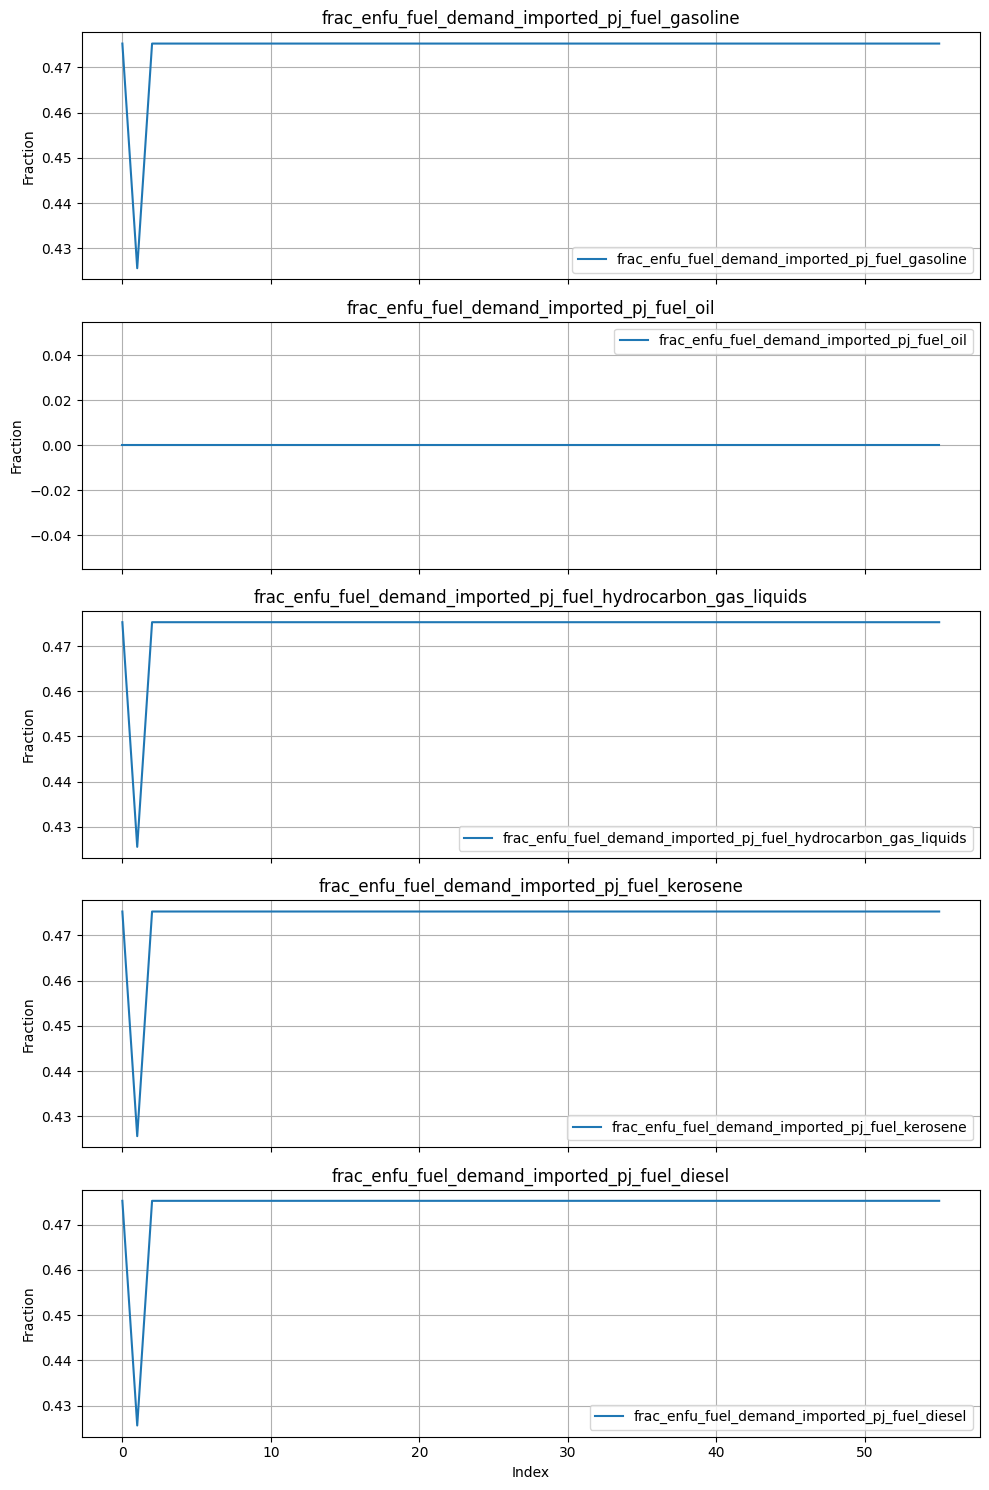

(<Figure size 1000x1500 with 5 Axes>,
 array([<Axes: title={'center': 'frac_enfu_fuel_demand_imported_pj_fuel_gasoline'}, ylabel='Fraction'>,
        <Axes: title={'center': 'frac_enfu_fuel_demand_imported_pj_fuel_oil'}, ylabel='Fraction'>,
        <Axes: title={'center': 'frac_enfu_fuel_demand_imported_pj_fuel_hydrocarbon_gas_liquids'}, ylabel='Fraction'>,
        <Axes: title={'center': 'frac_enfu_fuel_demand_imported_pj_fuel_kerosene'}, ylabel='Fraction'>,
        <Axes: title={'center': 'frac_enfu_fuel_demand_imported_pj_fuel_diesel'}, xlabel='Index', ylabel='Fraction'>],
       dtype=object))

In [28]:
plot_columns_subplots(
    df=df,
    columns=[f"frac_enfu_fuel_demand_imported_pj_fuel_{prod}" for prod in petroleum_products],
    ylabels=["Fraction"] * len(petroleum_products),

)

### Libya — Allocation of **petroleum product exports**

**Constraint (from IEA):** Total **petroleum product exports** = **120.034 PJ**.  
**IEA context:** Libya has **limited refining capacity** and **small refined-product exports**, so exports are dominated by “other oil products,” while **gasoline, diesel and kerosene** exports are minimal. Hydrocarbon gas liquids (HGL) can have some exports. (IEA Libya – Oil country page).

#### Allocation logic (qualitative → quantitative)
- **Gasoline, Diesel, Kerosene:** kept **very small** (Libya mostly imports these fuels).  
- **HGL (LPG/NGL):** allow a **modest share**.  
- **“Oil” (other oil products)**: catch-all for product exports not in the above (e.g., heavier or intermediate streams); it gets the **bulk**.

We assign the following **shares** and convert them to PJ so that they **sum to 120.034 PJ**:

| Product | Share of prod. exports | Exports (PJ) |
|:--|--:|--:|
| Gasoline | **1%** | **1.20034** |
| Diesel (gasoil) | **2%** | **2.40068** |
| Kerosene/Jet | **1%** | **1.20034** |
| Hydrocarbon Gas Liquids (HGL) | **15%** | **18.00510** |
| **Oil (other oil products)** | **81%** | **97.22754** |
| **Total** | **100%** | **120.03400** |

---

### Documentation notes
- **Source:** IEA (https://www.iea.org/countries/libya/oil)



In [29]:
new_exports_values = {
    "gasoline": 1.20034,
    "oil": 97.22754,
    "hydrocarbon_gas_liquids": 18.00510,
    "kerosene": 1.20034,
    "diesel": 2.40068
}

new_import_values = {
    "gasoline": 0.40,
    "oil": 0.05,
    "hydrocarbon_gas_liquids": 0.00,
    "kerosene": 0.20,
    "diesel": 0.30
}

for prod in petroleum_products:
    exports_var = f"exports_enfu_pj_fuel_{prod}"
    imports_var = f"frac_enfu_fuel_demand_imported_pj_fuel_{prod}"
    df[exports_var] = new_exports_values[prod]
    df[imports_var] = new_import_values[prod]

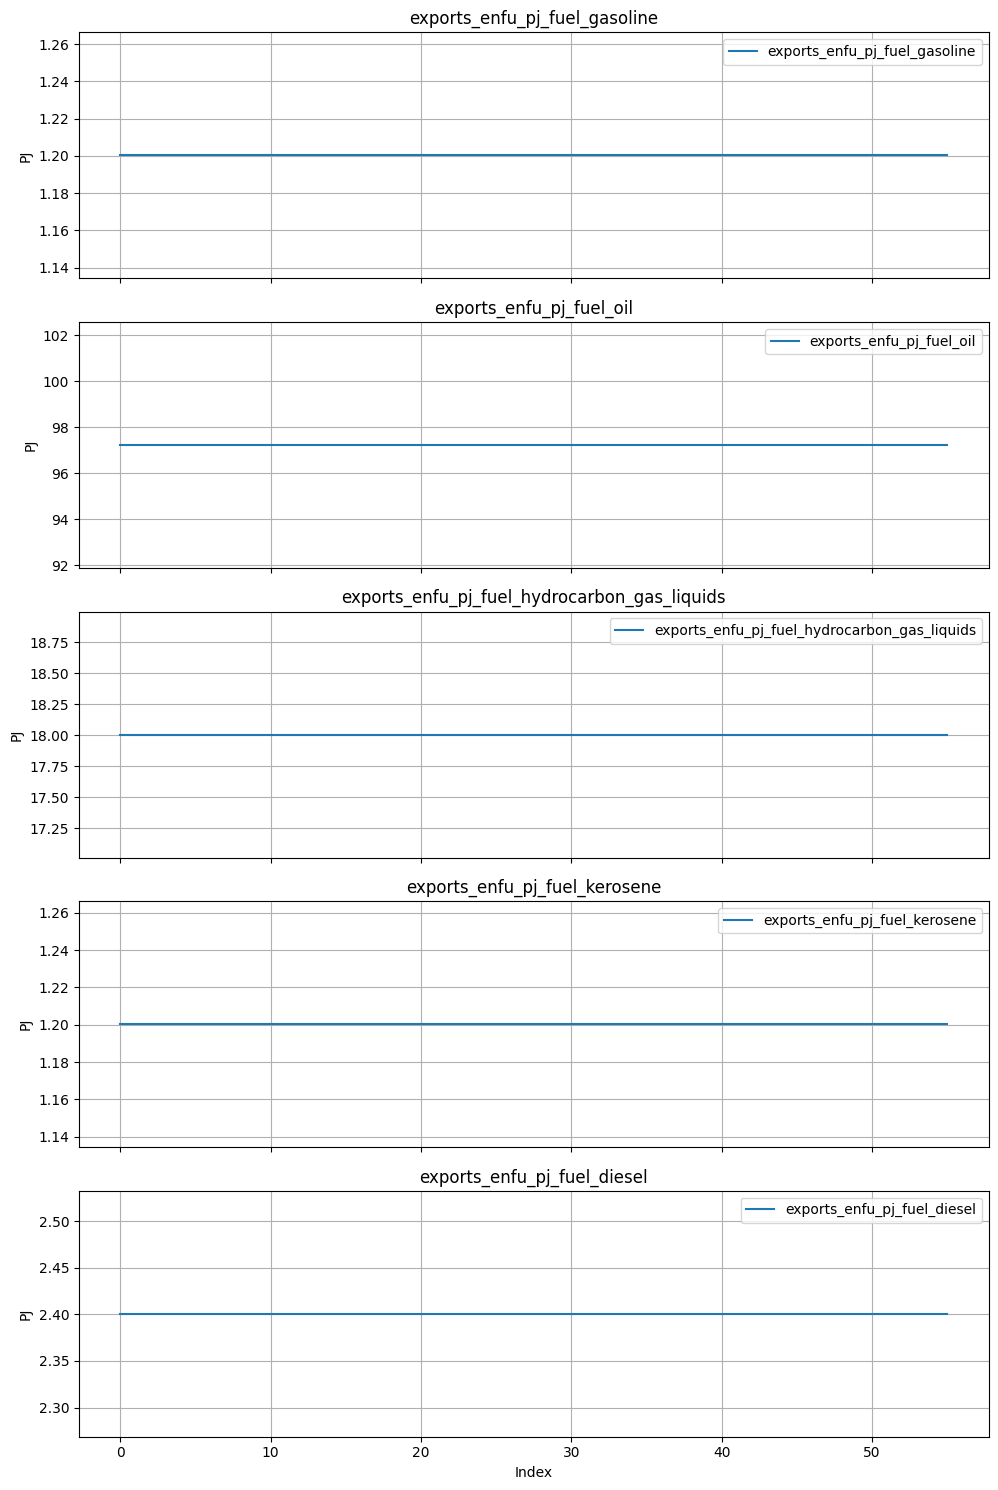

(<Figure size 1000x1500 with 5 Axes>,
 array([<Axes: title={'center': 'exports_enfu_pj_fuel_gasoline'}, ylabel='PJ'>,
        <Axes: title={'center': 'exports_enfu_pj_fuel_oil'}, ylabel='PJ'>,
        <Axes: title={'center': 'exports_enfu_pj_fuel_hydrocarbon_gas_liquids'}, ylabel='PJ'>,
        <Axes: title={'center': 'exports_enfu_pj_fuel_kerosene'}, ylabel='PJ'>,
        <Axes: title={'center': 'exports_enfu_pj_fuel_diesel'}, xlabel='Index', ylabel='PJ'>],
       dtype=object))

In [30]:
plot_columns_subplots(
    df=df,
    columns=[f"exports_enfu_pj_fuel_{prod}" for prod in petroleum_products],
    ylabels=["PJ"] * len(petroleum_products),

)

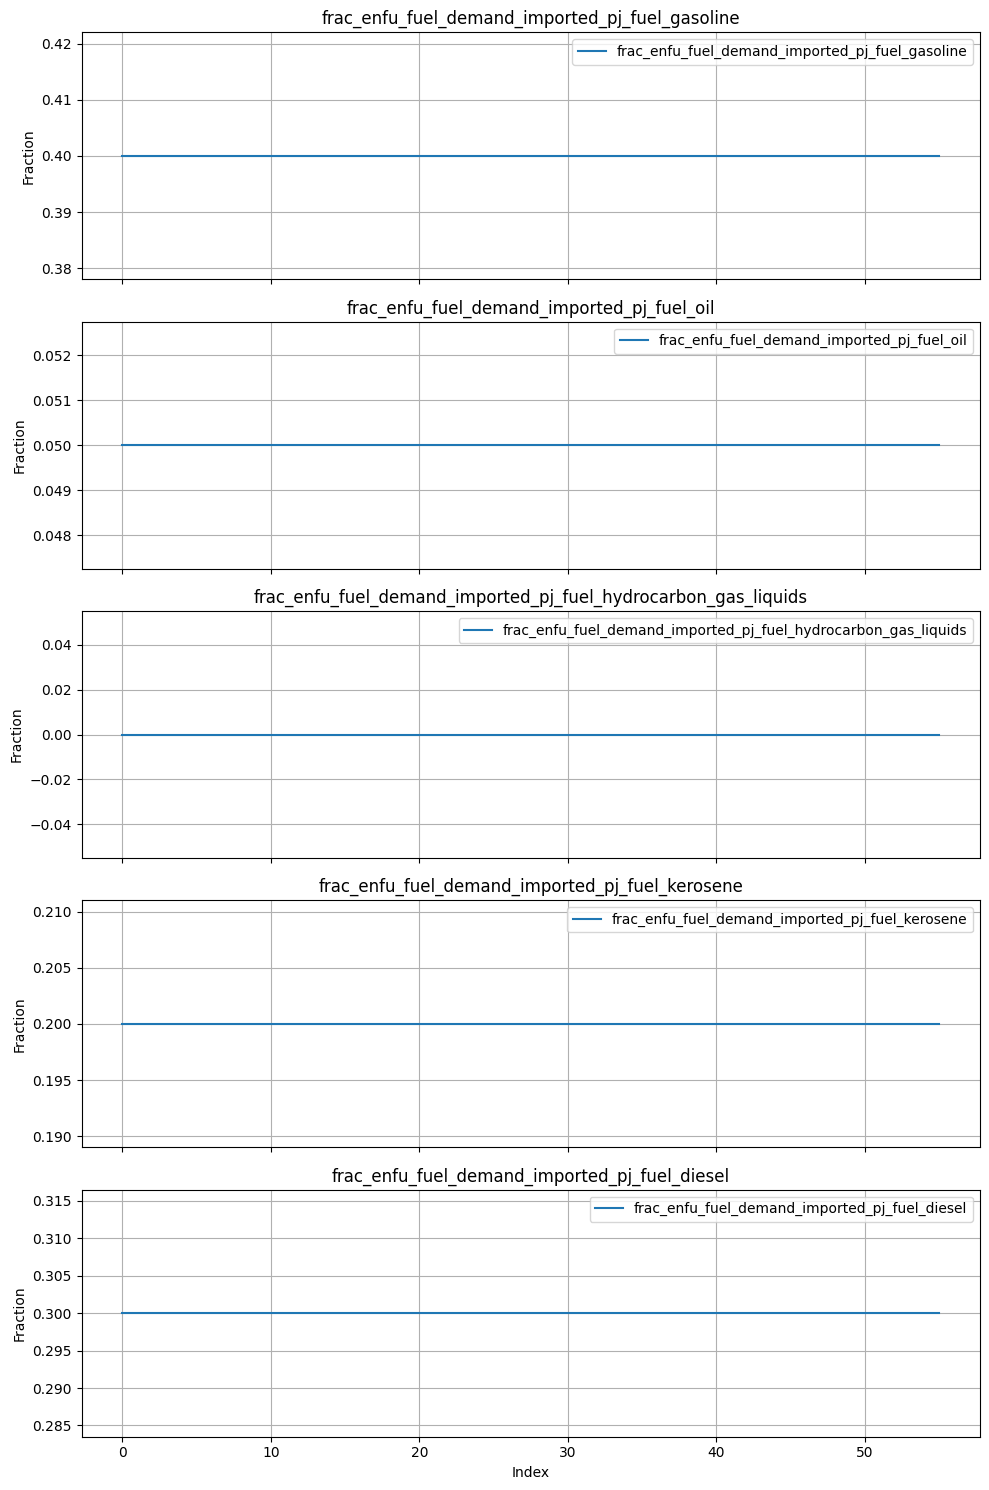

(<Figure size 1000x1500 with 5 Axes>,
 array([<Axes: title={'center': 'frac_enfu_fuel_demand_imported_pj_fuel_gasoline'}, ylabel='Fraction'>,
        <Axes: title={'center': 'frac_enfu_fuel_demand_imported_pj_fuel_oil'}, ylabel='Fraction'>,
        <Axes: title={'center': 'frac_enfu_fuel_demand_imported_pj_fuel_hydrocarbon_gas_liquids'}, ylabel='Fraction'>,
        <Axes: title={'center': 'frac_enfu_fuel_demand_imported_pj_fuel_kerosene'}, ylabel='Fraction'>,
        <Axes: title={'center': 'frac_enfu_fuel_demand_imported_pj_fuel_diesel'}, xlabel='Index', ylabel='Fraction'>],
       dtype=object))

In [31]:
plot_columns_subplots(
    df=df,
    columns=[f"frac_enfu_fuel_demand_imported_pj_fuel_{prod}" for prod in petroleum_products],
    ylabels=["Fraction"] * len(petroleum_products),

)

## Save modified df

In [32]:
df.to_csv("sisepuede_raw_inputs_latest_LBY_modified_oct_28.csv", index=False)